In [5]:
PP[u_, v_, Q_] := ((1-u)(u^2+A^2)-Q*u*v)u^2;
QQ[u_, v_, B_] := B(u-v)(u^2+A^2)v;

Q = (1 - H)(A^2 + H^2)/H^2;
B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);

2    2
       2                2          2    (-1 + H) (A  + H ) (H + u) (H + v)
(H + u)  ((1 - H - u) (A  + (H + u) ) + ----------------------------------)
                                                         2
                                                        H
    2    2               2          2
  (A  + H  (-1 + 2 H)) (A  + (H + u) ) (u - v) (H + v)
-(----------------------------------------------------)
                         2    2
                        A  + H
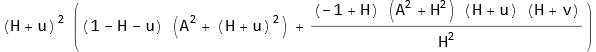
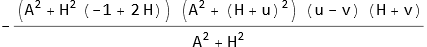

In [9]:
P1[u_, v_] = FullSimplify[PP[u + H, v + H, Q]]
Q1[u_, v_] = FullSimplify[QQ[u + H, v + H, B]]

In [11]:
jac = FullSimplify[{{D[P1[u, v], u], D[P1[u, v], v]}, {D[Q1[u, v], u], D[Q1[u, v], v]}}] /. {u -> 0, v -> 0}

2       2          2                2    2
{{-(A  H) - H  (-H + 2 H ), (-1 + H) H (A  + H )}, 
 
           2    2                   2    2
>   {-(H (A  + H  (-1 + 2 H))), H (A  + H  (-1 + 2 H))}}

In [12]:
detY[B_] = B H^2(A^2 + H^2)(H^3 + A^2(2 − H));
detJ = FullSimplify[Det[jac]]
Simplify[detY[b] - detJ]
Simplify[Tr[jac]]

2     2              3    2    2
-(H  (-(A  (-2 + H)) + H ) (A  + H  (-1 + 2 H)))
0
0

2             3    2    2
{{-(H Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]), 
 
                2             3    2    2
>    H Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]}, 
 
                   2             3    2    2
          Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
>   {{1 + ------------------------------------------------, 1}, 
                          2    2
                         A  + H  (-1 + 2 H)
 
                           2             3
                          A  (-2 + H) - H
>    {1 + ------------------------------------------------, 1}}}
                   2             3    2    2
          Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
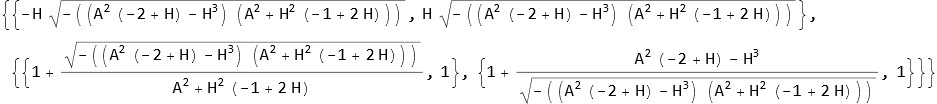

In [16]:
{vals, vecs} = FullSimplify[Eigensystem[jac]]

2             3
                     A  (-2 + H) - H
{1 + ------------------------------------------------, 1}
              2             3    2    2
     Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
           2             3    2    2
H Sqrt[-((A  (-2 + H) - H ) (A  + H  (-1 + 2 H)))]
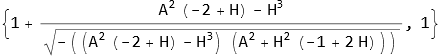

In [17]:
vectorp = FullSimplify[vecs[[2]]]
valorp = FullSimplify[vals[[2]]]

2             3
      A  (-2 + H) - H
Sqrt[------------------]
      2    2
     A  + H  (-1 + 2 H)
         2             3
        A  (-2 + H) - H
{{Sqrt[------------------], 1}, {0, 1}}
        2    2
       A  + H  (-1 + 2 H)
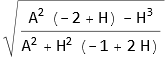
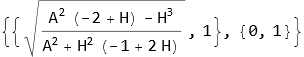

In [19]:
t = Sqrt[(A^2 (-2 + H) - H^3)^2/((A^2 + H^2 (-1 + 2H))(A^2(-2 + H)-H^3))]
imv2 = {t, 0};
rev2 = {1, 1};
P = Transpose[{imv2, rev2}]

2       2          2                    2    2
{(-(A  H) - H  (-H + 2 H )) u + (-1 + H) H (A  + H ) v, 
 
          2    2                      2    2
>   -(H (A  + H  (-1 + 2 H)) u) + H (A  + H  (-1 + 2 H)) v}
  2        3                                   2   2          2
{A  H u + H  (-1 + 2 H) u + (1 - H - u) (H + u)  (A  + (H + u) ) - 
 
                                         2    2         3
                  2    2      (-1 + H) (A  + H ) (H + u)  (H + v)
>    (-1 + H) H (A  + H ) v + -----------------------------------, 
                                               2
                                              H
 
        2    2                                        2          2
      (A  + H  (-1 + 2 H)) (u - v) (H u (2 H + u) + (A  + (H + u) ) v)
>   -(----------------------------------------------------------------)}
                                   2    2
                                  A  + H
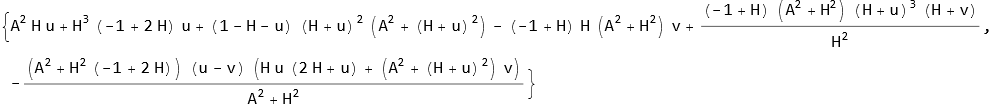

In [23]:
sistema = {P1[u, v], Q1[u, v]};
variables = {u, v};
lineal = jac . variables
noLineal = FullSimplify[sistema - lineal]

2               4                  2             3
        A  (-2 + H) H - H                  A  (-2 + H) - H      2    2
{{0, ------------------------}, {-(H Sqrt[------------------] (A  + H  (-1 + 2 H))), 0}}
            2             3                2    2
           A  (-2 + H) - H                A  + H  (-1 + 2 H)
     Sqrt[------------------]
           2    2
          A  + H  (-1 + 2 H)
                                    2             3
    2    2                         A  (-2 + H) - H
{((A  + H  (-1 + 2 H)) x (H (Sqrt[------------------] x + y) 
                                   2    2
                                  A  + H  (-1 + 2 H)
 
                         2             3
                        A  (-2 + H) - H
>          (2 H + Sqrt[------------------] x + y) + 
                        2    2
                       A  + H  (-1 + 2 H)
 
                              2             3
              2              A  (-2 + H) - H          2        2    2
>         y (A  + (H + Sqrt[------------------] x + y) ))) / (A  + H ) + 
                             2    2
                            A  + H  (-1 + 2 H)
 
                                               2             3
                     2    2        2          A  (-2 + H) - H
>    (-((-1 + H) H (A  + H ) y) + A  H (Sqrt[------------------] x + y) + 
                                              2    2
                                             A  + H  (-1 + 2 H)
 
                              2             3
         3                   A  (-2 + H) - H
>       H  (-1 + 2 H) (Sqrt[------------------] x + y) + 
                             2    2
                            A  + H  (-1 + 2 H)
 
                                               2             3
                   2    2                     A  (-2 + H) - H          3
        (-1 + H) (A  + H ) (H + y) (H + Sqrt[------------------] x + y)
                                              2    2
                                             A  + H  (-1 + 2 H)
>       ---------------------------------------------------------------- + 
                                        2
                                       H
 
                        2             3                      2             3
                       A  (-2 + H) - H                      A  (-2 + H) - H          2
>       (1 - H - Sqrt[------------------] x - y) (H + Sqrt[------------------] x + y)  
                       2    2                               2    2
                      A  + H  (-1 + 2 H)                   A  + H  (-1 + 2 H)
 
                           2             3                      2             3
           2              A  (-2 + H) - H          2           A  (-2 + H) - H
>        (A  + (H + Sqrt[------------------] x + y) )) / Sqrt[------------------], 
                          2    2                               2    2
                         A  + H  (-1 + 2 H)                   A  + H  (-1 + 2 H)
 
              2             3
             A  (-2 + H) - H      2    2
>   -((Sqrt[------------------] (A  + H  (-1 + 2 H)) x 
             2    2
            A  + H  (-1 + 2 H)
 
                    2             3                        2             3
                   A  (-2 + H) - H                        A  (-2 + H) - H
>        (H (Sqrt[------------------] x + y) (2 H + Sqrt[------------------] x + y) + 
                   2    2                                 2    2
                  A  + H  (-1 + 2 H)                     A  + H  (-1 + 2 H)
 
                               2             3
               2              A  (-2 + H) - H          2        2    2
>          y (A  + (H + Sqrt[------------------] x + y) ))) / (A  + H ))}
                              2    2
                             A  + H  (-1 + 2 H)
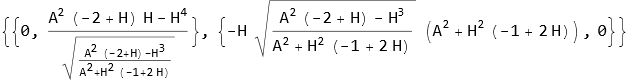
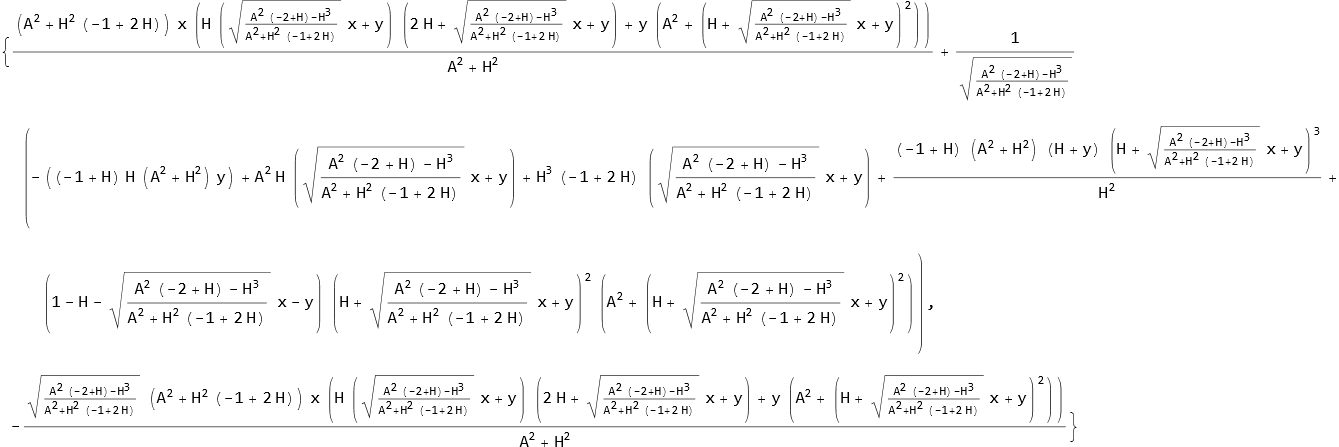

In [27]:
varsO = {u, v};
varsN = {x, y};
cambio = Thread[varsO -> P . varsN];
inv = Inverse[P];
matrizNormal = FullSimplify[inv . jac . P]
nonLinearNormal = FullSimplify[inv . (noLineal /. cambio)]

2             3
        A  (-2 + H) - H      2    2
H Sqrt[------------------] (A  + H  (-1 + 2 H)) - 
        2    2
       A  + H  (-1 + 2 H)
 
          2   2             3    2    2
>   Sqrt[H  (A  (-2 + H) - H ) (A  + H  (-1 + 2 H))]
                           2             3
     2    2      3        A  (-2 + H) - H
H (-A  + H  - 2 H ) Sqrt[------------------] + 
                          2    2
                         A  + H  (-1 + 2 H)
 
          2   2             3    2    2
>   Sqrt[H  (A  (-2 + H) - H ) (A  + H  (-1 + 2 H))]
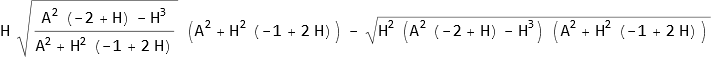
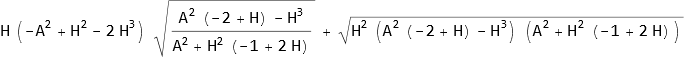

In [33]:
FullSimplify[matrizNormal[[1, 2]] - Sqrt[detY[b]]]
FullSimplify[matrizNormal[[2, 1]] + Sqrt[detY[b]]]

2      2        3   2        2      2        3   3
(-5 A  + 3 A  H - 4 H ) y    (-4 A  + 3 A  H - 6 H ) y
-------------------------- + -------------------------- + 
        2             3               2             3
       A  (-2 + H) - H               A  (-2 + H) - H
 Sqrt[------------------]    H Sqrt[------------------]
       2    2                        2    2
      A  + H  (-1 + 2 H)            A  + H  (-1 + 2 H)
 
            2      2  2    4
     3  -2 A  H + A  H  - H        4    4        2  2       2  3      2  4      5
>   x  (-------------------- + (2 A  - A  H - 6 A  H  + 22 A  H  - 9 A  H  - 3 H  + 
               2    2
              A  + H
 
             6         2    2      3
>         9 H ) / (H (A  - H  + 2 H )) + 
 
            2    2      3
        -2 A  + A  H - H        4      4        2  2    4  2       2  3       2  4
>      (----------------- + (2 A  - 3 A  H - 6 A  H  + A  H  + 42 A  H  - 20 A  H  - 
              2    2
             A  + H
 
                                                               2    2      3   2
                5       6      2   2    2      3        10 (2 A  - A  H + H ) y
>            3 H  + 19 H ) / (H  (A  - H  + 2 H ))) y + ------------------------) + 
                                                              2    2      3
                                                             A  - H  + 2 H
 
     2      6      6        4  2       4  3      2  4      4  4      2  5      2  6
>   x  ((4 A  - 2 A  H - 6 A  H  + 19 A  H  - 2 A  H  - 7 A  H  + 4 A  H  + 4 A  H  - 
 
                                           2    2      3
           7      8       2    2       -2 A  + A  H - H     2    2      3
>         H  + 3 H ) / ((A  + H ) Sqrt[-----------------] (A  - H  + 2 H )) + 
                                         2    2      3
                                        A  - H  + 2 H
 
             6       6        4  2      6  2       4  3      2  4       4  4
>      ((12 A  - 12 A  H - 8 A  H  + 3 A  H  + 52 A  H  - 4 A  H  - 24 A  H  + 
 
                2  5      2  6      7       8
>           30 A  H  + 5 A  H  - 2 H  + 16 H ) y) / 
 
                              2    2      3
             2    2       -2 A  + A  H - H     2    2      3
>       (H (A  + H ) Sqrt[-----------------] (A  - H  + 2 H )) + 
                            2    2      3
                           A  - H  + 2 H
 
            6      6        4  2      6  2       4  3      2  4       4  4       2  5
>      ((6 A  - 9 A  H - 4 A  H  + 3 A  H  + 53 A  H  - 2 A  H  - 27 A  H  + 45 A  H  + 
 
             2  6    7       8   2
>           A  H  - H  + 23 H ) y ) / 
 
                               2    2      3
          2   2    2       -2 A  + A  H - H     2    2      3
>       (H  (A  + H ) Sqrt[-----------------] (A  - H  + 2 H )) + 
                             2    2      3
                            A  - H  + 2 H
 
                      2    2      3   3
               10 (2 A  - A  H + H ) y
>      ----------------------------------------) + 
                2    2      3
            -2 A  + A  H - H     2    2      3
       Sqrt[-----------------] (A  - H  + 2 H )
              2    2      3
             A  - H  + 2 H
 
             4      4        2  2      2  3      5         2    2
>   x (((-6 A  + 3 A  H - 2 A  H  - 6 A  H  - 5 H ) y) / (A  + H ) - 
 
              4      4      2  2      2  3      5   2         2    2
>      (3 (3 A  - 2 A  H + A  H  + 5 A  H  + 5 H ) y ) / (H (A  + H )) + 
 
             4      4      2  2       2  3       5   3      2   2    2
>      ((-3 A  + 3 A  H - A  H  - 14 A  H  - 15 H ) y ) / (H  (A  + H )))
             2    2      3
         -2 A  + A  H - H       2      2  2    4
    Sqrt[-----------------] (2 A  H - A  H  + H )
           2    2      3
 3        A  - H  + 2 H
x  (--------------------------------------------- + 
                        2    2
                       A  + H
 
                                   2    2      3
       
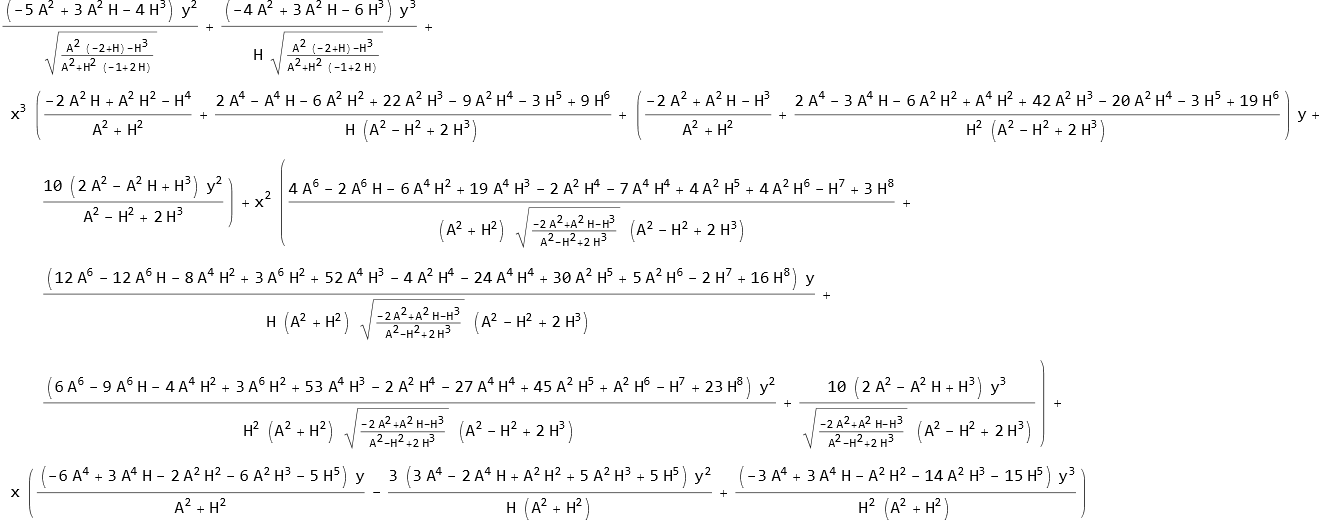
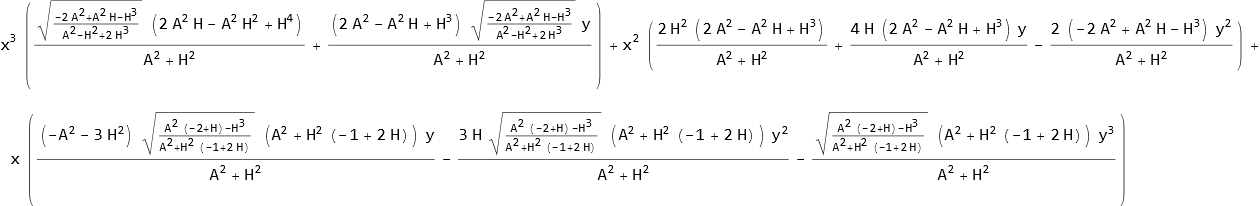

In [35]:
f1 = nonLinearNormal[[1]];
g1 = nonLinearNormal[[2]];
fn = Normal[Series[f1, {x, 0, 3}, {y, 0, 3}]]
gn = Normal[Series[g1, {x, 0, 3}, {y, 0, 3}]]

2             3
       4    2            2    4      5        A  (-2 + H) - H
2 (-2 A  + A  (3 - 7 H) H  + H  - 3 H ) Sqrt[------------------]
                                              2    2
                                             A  + H  (-1 + 2 H)
----------------------------------------------------------------
                             2    2
                            A  + H
    3      2
-8 H  + 2 A  (-5 + 3 H)
------------------------
       2             3
      A  (-2 + H) - H
Sqrt[------------------]
      2    2
     A  + H  (-1 + 2 H)
   4               5      2  2
3 A  (-2 + H) - 5 H  - 2 A  H  (1 + 3 H)
----------------------------------------
                 2    2
                A  + H
      2              3    4      2  2               4
6 (-(A  (-2 + H)) + H ) (A  + 3 A  H  (-1 + 3 H) + H  (-2 + 7 H))
-----------------------------------------------------------------
                    2    2    2    2
                H (A  + H ) (A  + H  (-1 + 2 H))
       2             2   2
   -3 A       2   2 A  (A  + H)
6 (----- - 5 H  + -------------)
     H                2    2
                     A  + H
   2     2              3
4 H  (-(A  (-2 + H)) + H )
--------------------------
          2    2
         A  + H
0
                     2             3
    2      2        A  (-2 + H) - H      2    2
  (A  + 3 H ) Sqrt[------------------] (A  + H  (-1 + 2 H))
                    2    2
                   A  + H  (-1 + 2 H)
-(---------------------------------------------------------)
                            2    2
                           A  + H
        2              3
8 H (-(A  (-2 + H)) + H )
-------------------------
          2    2
         A  + H
0
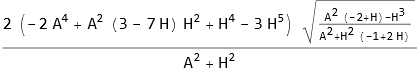
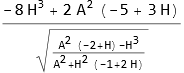
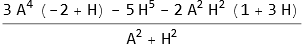
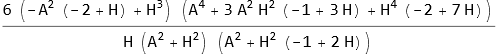
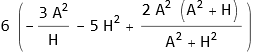
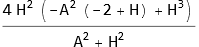
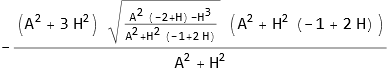
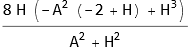

In [39]:
fxx  = FullSimplify[2  * SeriesCoefficient[fn, {x,0,2}, {y,0,0}]]
fyy  = FullSimplify[2  * SeriesCoefficient[fn, {x,0,0}, {y,0,2}]]
fxy  = FullSimplify[1  * SeriesCoefficient[fn, {x,0,1}, {y,0,1}]]
fxxx = FullSimplify[6  * SeriesCoefficient[fn, {x,0,3}, {y,0,0}]]
fxyy = FullSimplify[2  * SeriesCoefficient[fn, {x,0,1}, {y,0,2}]]

gxx  = FullSimplify[2  * SeriesCoefficient[gn, {x,0,2}, {y,0,0}]]
gyy  = FullSimplify[2  * SeriesCoefficient[gn, {x,0,0}, {y,0,2}]]
gxy  = FullSimplify[1  * SeriesCoefficient[gn, {x,0,1}, {y,0,1}]]
gxxy = FullSimplify[2  * SeriesCoefficient[gn, {x,0,2}, {y,0,1}]]
gyyy = FullSimplify[6  * SeriesCoefficient[gn, {x,0,0}, {y,0,3}]]

8                               10    2  7
(-3 A  (-2 + H) (-1 + H) - (-5 + H) H   + A  H  (-13 + (58 - 33 H) H) + 
 
       6  3                         4  4
>     A  H  (21 + H (-26 + 9 H)) + A  H  (-34 + H (119 + H (-90 + 17 H)))) / 
 
           2    2      2              3    2    2
>   (4 H (A  + H ) (-(A  (-2 + H)) + H ) (A  + H  (-1 + 2 H)))
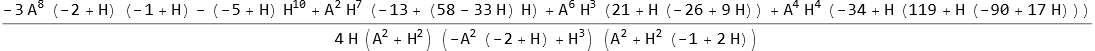

In [49]:
omega = Sqrt[detY[b]];

L1 = (1/16) * (
  (fxxx + fxyy + gxxy + gyyy) +
  (1/omega) * (fxy*(fxx + fyy) - gxy*(gxx + gyy) - fxx*gxx + fyy*gyy)
);

Assuming[
  {A > 0, 0 < H < 1/2, A^2 + H^2 > 0,
   A^2*(H-2) - H^3 < 0,
   A^2 + H^2*(2H-1) > 0},
  FullSimplify[L1]
]

In [52]:
l1[a_, h_] := L1 /. {A -> a, H -> h};

In [53]:
resultados = Table[
  Module[{h, maxa, a},
    h = RandomReal[{0.001, 0.499}];
    maxa = Sqrt[h^2 (1 - 2 h)];
    a = RandomReal[{0.001, maxa}];
    {a, h, l1[a, h]}
  ],
  {10}
]

{{0.0416651, 0.457261, -0.0331738}, {0.164653, 0.255566, -0.308452}, 
 
>   {0.0157408, 0.230868, -0.00207221}, {0.132973, 0.44736, -1.31385}, 
 
>   {0.0147775, 0.0649645, -0.00215612}, {0.0963798, 0.22213, -0.04737}, 
 
>   {0.047613, 0.154141, -0.0136399}, {0.00564676, 0.320631, -0.000252151}, 
 
>   {0.00199769, 0.00538675, 0.0000756605}, {0.0133316, 0.0249358, 0.00142119}}

In [54]:
Clear[a, b, c, A, B, H, Q];

In [55]:
h1[u_, v_] = PP[u + H, v + H, Q] ;
h2[u_, v_] = QQ[u + H, v + H, B] ;
F1[u_, v_] = h1[u, v] - a*u - b*v ;
F2[u_, v_] = h2[u, v] - a*u + a*v ;
G1[u_, v_] = (1/c)(F1[u, v] - F2[u, v]);
G2[u_, v_] = F2[u, v];

2               2    2      2
H  (-((-1 + H) (A  + H )) - H  Q)
--------------------------------- + 
                c
 
                 2        2  2      3      4      3
    (-a - b + 2 A  H - 3 A  H  + 4 H  - 5 H  - 4 H  Q) Y
>   ---------------------------------------------------- + 
                             c
 
      2      2        2       3      2     2      2             2           3
    (A  - 3 A  H + 6 H  - 10 H  - 6 H  Q) Y    (-A  + 4 H - 10 H  - 4 H Q) Y
>   ---------------------------------------- + ------------------------------ + 
                       c                                     c
 
     3     2   2                   2            2                             2  2
>   X  (-(c  (A  - 4 H + B H + 10 H  + H Q)) - c  (-4 + B + 20 H + Q) Y - 10 c  Y ) + 
 
     2      2      2        2        2       3      2
>   X  (c (A  - 3 A  H + 6 H  - 2 B H  - 10 H  - 3 H  Q) + 
 
              2                      2                                        2         3
>      c (-3 A  + 12 H - 4 B H - 30 H  - 6 H Q) Y + c (6 - 2 B - 30 H - 3 Q) Y  - 10 c Y
 
                 2      2          2  2      3      3      4      3
>      ) + X (2 A  H - A  B H - 3 A  H  + 4 H  - B H  - 5 H  - 3 H  Q + 
 
           2    2        2         2        2       3      2
>      (2 A  - A  B - 6 A  H + 12 H  - 3 B H  - 20 H  - 9 H  Q) Y - 
 
           2                   2           2                         3
>      3 (A  - 4 H + B H + 10 H  + 3 H Q) Y  + (4 - B - 20 H - 3 Q) Y )
 3     3        3       2       2  2        2            2  2
X  (B c  H + B c  Y) + X  (2 B c  H  + 4 B c  H Y + 2 B c  Y ) + 
 
                        2    2          2      2               2        3
>   X (-(a c) + B c H (A  + H ) + B c (A  + 3 H ) Y + 3 B c H Y  + B c Y )
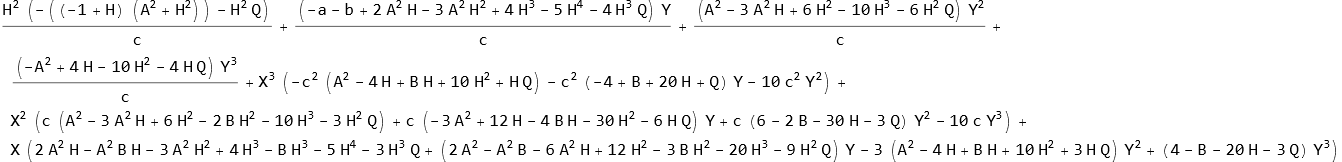

In [61]:
(* B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
Q = (1 - H)(A^2 + H^2)/H^2;
a = H(H^{2}(1-2H)-A^2);
b = -H((1-H)(A^2+H^2));
c = Sqrt[(H^3+A^2(2-H))/(H^2(1-2H) - A^2)];
*)
funo = Normal[Series[G1[c*X + Y, Y], {X, 0, 3}, {Y, 0, 3}]]
fundos = Normal[Series[G2[c*X + Y, Y], {X, 0, 3}, {Y, 0, 3}]]

2              2
2 c (A  (1 - 3 H) - H  (-6 + 2 B + 10 H + 3 Q))
 2                2
A  (2 - 6 H) - 4 H  (-3 + 5 H + 3 Q)
------------------------------------
                 c
   2                    2
-(A  (-2 + B + 6 H)) - H  (-12 + 3 B + 20 H + 9 Q)
    2   2
-6 c  (A  + H (-4 + B + 10 H + Q))
     2
-6 (A  + H (-4 + B + 10 H + 3 Q))
     2  2
4 B c  H
0
      2      2
B c (A  + 3 H )
     2
8 B c  H
0
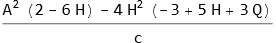

In [64]:
derxx  = FullSimplify[2  * SeriesCoefficient[funo, {X,0,2}, {Y,0,0}]]
deryy  = FullSimplify[2  * SeriesCoefficient[funo, {X,0,0}, {Y,0,2}]]
derxy  = FullSimplify[1  * SeriesCoefficient[funo, {X,0,1}, {Y,0,1}]]
derxxx = FullSimplify[6  * SeriesCoefficient[funo, {X,0,3}, {Y,0,0}]]
derxyy = FullSimplify[2  * SeriesCoefficient[funo, {X,0,1}, {Y,0,2}]]

der0xx  = FullSimplify[2  * SeriesCoefficient[fundos, {X,0,2}, {Y,0,0}]]
der0yy  = FullSimplify[2  * SeriesCoefficient[fundos, {X,0,0}, {Y,0,2}]]
der0xy  = FullSimplify[1  * SeriesCoefficient[fundos, {X,0,1}, {Y,0,1}]]
der0xxy = FullSimplify[2  * SeriesCoefficient[fundos, {X,0,2}, {Y,0,1}]]
der0yyy = FullSimplify[6  * SeriesCoefficient[fundos, {X,0,0}, {Y,0,3}]]

2        2   2                                2
(8 B c  H - 6 c  (A  + H (-4 + B + 10 H + Q)) - 6 (A  + H (-4 + B + 10 H + 3 Q)) + 
 
           2  3  2   2      2         3  2   2              2
>     (-4 B  c  H  (A  + 3 H ) - 8 B c  H  (A  (1 - 3 H) - H  (-6 + 2 B + 10 H + 3 Q)) + 
 
              2                   2
>        (2 (A  (-2 + B + 6 H) + H  (-12 + 3 B + 20 H + 9 Q)) 
 
              2       2                2                     2
>           (A  (1 + c ) (-1 + 3 H) + H  (-6 + 10 H + 6 Q + c  (-6 + 2 B + 10 H + 3 Q))))
 
                         2    2    2      3      2              3
>           / c) / Sqrt[H  (-A  + H  - 2 H ) (-(A  (-2 + H)) + H )]) / 16
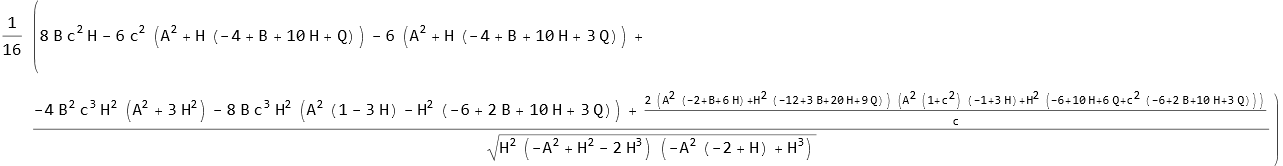

In [74]:
lyapunov = (1/16) * (
  (derxxx + derxyy + der0xxy + der0yyy) +
  (1/omega) * (derxy*(derxx + deryy) - der0xy*(der0xx + der0yy) - derxx*der0xx + deryy*der0yy)
);

FullSimplify[lyapunov]

0
    4    2            2    4      5
-2 A  + A  (3 - 7 H) H  + H  - 3 H
-----------------------------------
               2    2
              A  + H
    3      2
-8 H  + 2 A  (-5 + 3 H)
   4               5      2  2
3 A  (-2 + H) - 5 H  - 2 A  H  (1 + 3 H)
----------------------------------------
                 2    2
                A  + H
 4      2  2               4
A  + 3 A  H  (-1 + 3 H) + H  (-2 + 7 H)
---------------------------------------
                  2    2
              H (A  + H )
   2             2   2
3 A       2   2 A  (A  + H)
---- + 5 H  - -------------
 H                2    2
                 A  + H
   2     2              3
4 H  (-(A  (-2 + H)) + H )
--------------------------
          2    2
         A  + H
                 2             3
        2       A  (-2 + H) - H      2    2
       A  Sqrt[------------------] (A  + H  (-1 + 2 H))
                2    2
   2           A  + H  (-1 + 2 H)
3 H  - ------------------------------------------------
                            2    2
                           A  + H
        2              3
8 H (-(A  (-2 + H)) + H )
-------------------------
          2    2
         A  + H
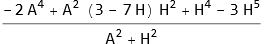
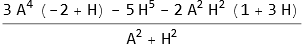
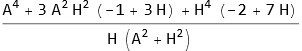
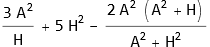
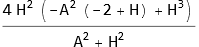
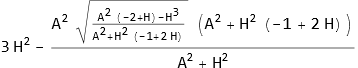
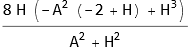

In [111]:
Clear[a, b, c, A, B, H, Q];

B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
Q = (1 - H)(A^2 + H^2)/H^2;
a = H(H^{2}(1-2H)-A^2);
b = -H((1-H)(A^2+H^2));
c = Sqrt[(H^3+A^2(2-H))/(H^2(1-2H) - A^2)];

FullSimplify[lyapunov - L1]

re1 = FullSimplify[A^2 (1-3 H)-H^2 (2 B+10 H+3 Q-6)]
re2 = FullSimplify[A^2 (2-6 H)-4 H^2 (5 H+3 Q-3)]
re3 = FullSimplify[-(A^2 (B+6 H-2))-H^2 (3 B+20 H+9 Q-12)]
re4 = FullSimplify[A^2+H (B+10 H+Q-4)]
re5 = FullSimplify[A^2+H (B+10 H+3 Q-4)]

re6 = FullSimplify[4 B c^2 H^2]
re7 = FullSimplify[B c A^2+3 H^2]
re8 = FullSimplify[8 B c^2 H]

Clear[a, b, c, A, B, H, Q];

In [134]:
CopyToClipboard[ToString[TeXForm[re8]]]